In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

df = pd.read_csv("superstore_cleaned.csv")

print(df.shape)

(9994, 27)


In [69]:
segment_sales = (
    df.groupby("segment")["sales"]
      .sum()
      .sort_values(ascending=False)
)

print(segment_sales)

segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: sales, dtype: float64


In [70]:
segment_profit = (
    df.groupby("segment")["profit"]
      .sum()
      .sort_values(ascending=False)
)

print(segment_profit)

segment
Consumer       134119.2092
Corporate       91979.1340
Home Office     60298.6785
Name: profit, dtype: float64


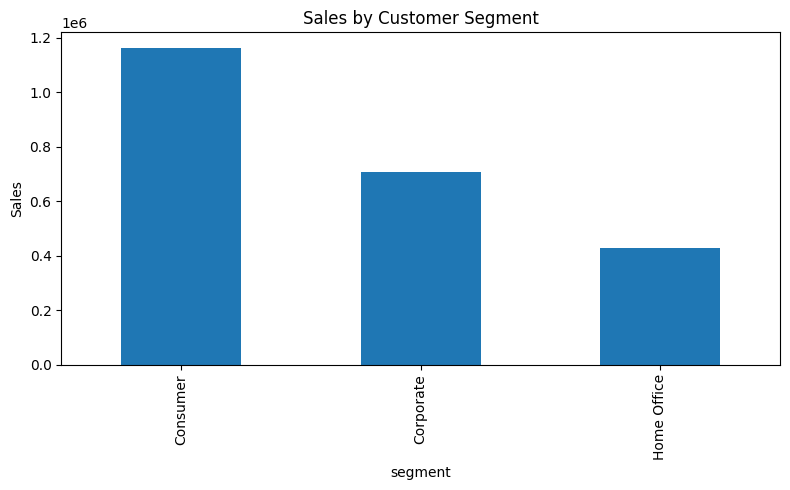

In [71]:
plt.figure(figsize=(8,5))

segment_sales.plot(kind="bar")

plt.title("Sales by Customer Segment")
plt.ylabel("Sales")

plt.tight_layout()
plt.savefig("segment_sales.png", dpi=300)
plt.show()

In [72]:
top_states = (
    df.groupby("state")["sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_states)

state
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Florida          89473.7080
Illinois         80166.1010
Ohio             78258.1360
Michigan         76269.6140
Virginia         70636.7200
Name: sales, dtype: float64


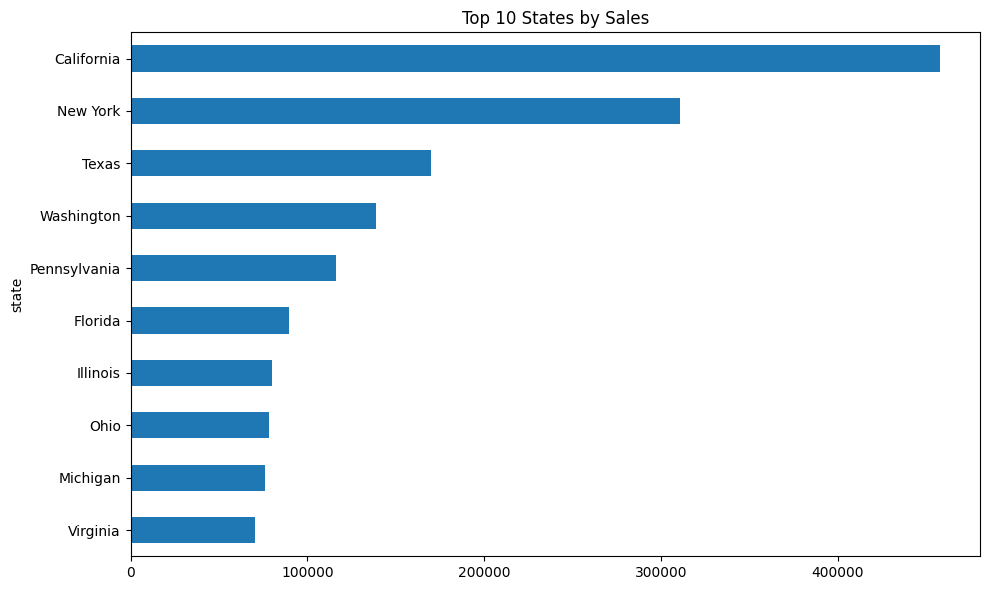

In [73]:
plt.figure(figsize=(10,6))

top_states.sort_values().plot(kind="barh")

plt.title("Top 10 States by Sales")

plt.tight_layout()
plt.savefig("top_states.png", dpi=300)

plt.show()

In [74]:
top_cities = (
    df.groupby("city")["sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_cities)

city
New York City    256368.1610
Los Angeles      175851.3410
Seattle          119540.7420
San Francisco    112669.0920
Philadelphia     109077.0130
Houston           64504.7604
Chicago           48539.5410
San Diego         47521.0290
Jacksonville      44713.1830
Springfield       43054.3420
Name: sales, dtype: float64


In [75]:
discount_profit = (
    df.groupby("discount")
      ["profit"]
      .mean()
      .reset_index()
)

print(discount_profit)

    discount      profit
0       0.00   66.900292
1       0.10   96.055074
2       0.15   27.288298
3       0.20   24.702572
4       0.30  -45.679636
5       0.32  -88.560656
6       0.40 -111.927429
7       0.45 -226.646464
8       0.50 -310.703456
9       0.60  -43.077212
10      0.70  -95.874060
11      0.80 -101.796797


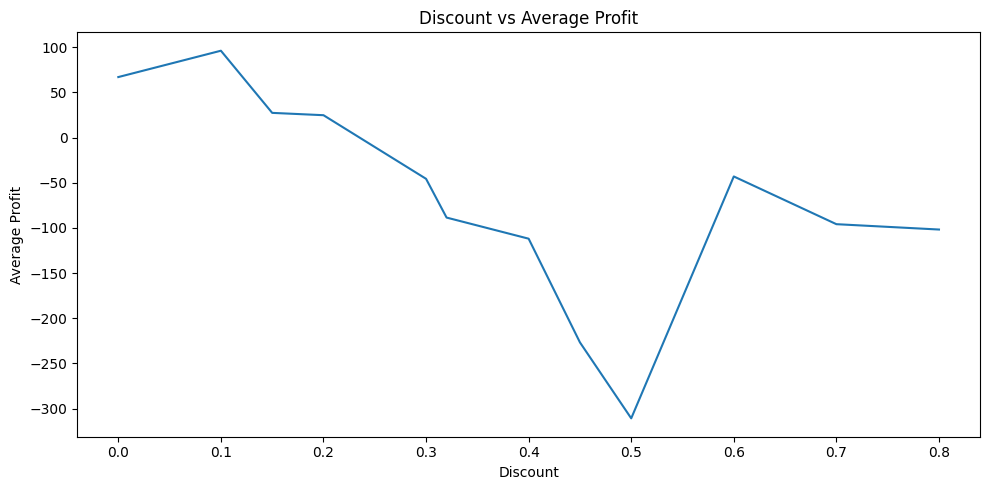

In [76]:
plt.figure(figsize=(10,5))

plt.plot(
    discount_profit["discount"],
    discount_profit["profit"]
)

plt.title("Discount vs Average Profit")

plt.xlabel("Discount")
plt.ylabel("Average Profit")

plt.tight_layout()
plt.savefig("discount_vs_profit.png", dpi=300)

plt.show()

In [77]:
loss_products = (
    df.groupby("product_name")["profit"]
      .sum()
      .sort_values()
      .head(10)
)

print(loss_products)

product_name
Cubify CubeX 3D Printer Double Head Print                           -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                           -4589.9730
Cubify CubeX 3D Printer Triple Head Print                           -3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases            -2876.1156
Bush Advantage Collection Racetrack Conference Table                -1934.3976
GBC DocuBind P400 Electric Binding System                           -1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit               -1811.0784
Martin Yale Chadless Opener Electric Letter Opener                  -1299.1836
Balt Solid Wood Round Tables                                        -1201.0581
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables   -1148.4375
Name: profit, dtype: float64


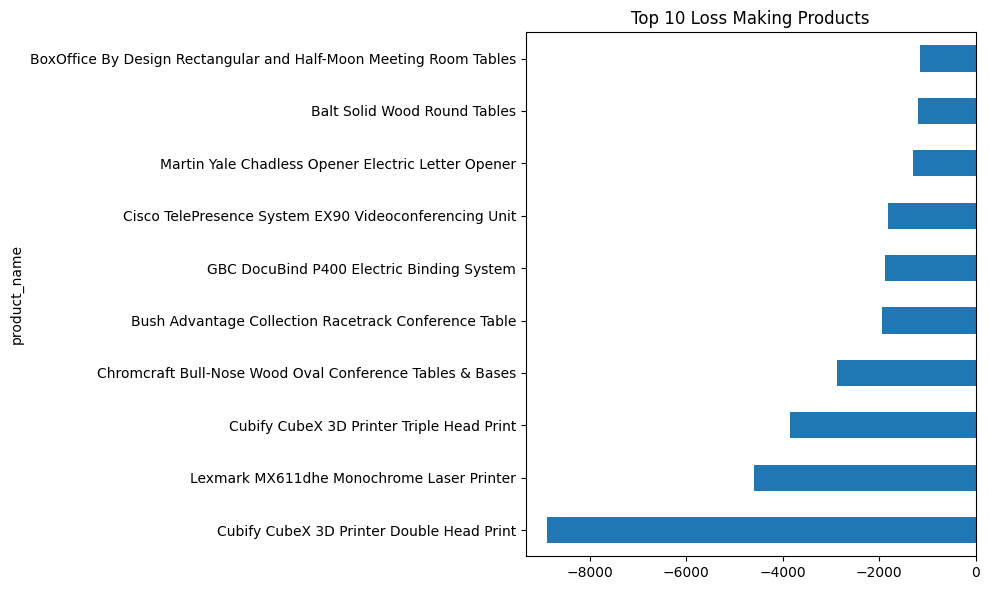

In [78]:
plt.figure(figsize=(10,6))

loss_products.plot(kind="barh")

plt.title("Top 10 Loss Making Products")

plt.tight_layout()
plt.savefig("loss_products.png", dpi=300)

plt.show()

In [79]:
category_profit = (
    df.groupby("category")["profit"]
      .sum()
      .sort_values()
)

print(category_profit)

category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: profit, dtype: float64


In [80]:
top_profit_customers = (
    df.groupby("customer_name")["profit"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_profit_customers)

customer_name
Tamara Chand            8981.3239
Raymond Buch            6976.0959
Sanjit Chand            5757.4119
Hunter Lopez            5622.4292
Adrian Barton           5444.8055
Tom Ashbrook            4703.7883
Christopher Martinez    3899.8904
Keith Dawkins           3038.6254
Andy Reiter             2884.6208
Daniel Raglin           2869.0760
Name: profit, dtype: float64


In [81]:
customer_orders = (
    df.groupby("customer_name")["order_id"]
      .nunique()
      .sort_values(ascending=False)
      .head(10)
)

print(customer_orders)

customer_name
Emily Phan             17
Sally Hughsby          13
Noel Staavos           13
Patrick Gardner        13
Zuschuss Carroll       13
Joel Eaton             13
Erin Ashbrook          13
Chloris Kastensmidt    13
Suzanne McNair         12
Rick Bensley           12
Name: order_id, dtype: int64


In [82]:
# ==========================
# DAY 5 BUSINESS FINDINGS
# ==========================

# Highest Revenue Segment
highest_revenue_segment = (
    df.groupby("segment")["sales"]
      .sum()
      .sort_values(ascending=False)
)

# Best State
best_state = (
    df.groupby("state")["sales"]
      .sum()
      .sort_values(ascending=False)
)

# Best City
best_city = (
    df.groupby("city")["sales"]
      .sum()
      .sort_values(ascending=False)
)

# Top Loss-Making Product
top_loss_product = (
    df.groupby("product_name")["profit"]
      .sum()
      .sort_values()
)

# Top Profit Customer
top_profit_customer = (
    df.groupby("customer_name")["profit"]
      .sum()
      .sort_values(ascending=False)
)

# Most Loyal Customer
most_loyal_customer = (
    df.groupby("customer_name")["order_id"]
      .nunique()
      .sort_values(ascending=False)
)

# Discount Impact
discount_profit = (
    df.groupby("discount")["profit"]
      .mean()
      .reset_index()
)

correlation = df["discount"].corr(df["profit"])

print("===== DAY 5 RESULTS =====\n")

print("Highest Revenue Segment:")
print(highest_revenue_segment.head(1))
print()

print("Best State:")
print(best_state.head(1))
print()

print("Best City:")
print(best_city.head(1))
print()

print("Top Loss-Making Product:")
print(top_loss_product.head(1))
print()

print("Top Profit Customer:")
print(top_profit_customer.head(1))
print()

print("Most Loyal Customer:")
print(most_loyal_customer.head(1))
print()

print("Discount-Profit Correlation:")
print(round(correlation, 4))

if correlation < 0:
    print("\nConclusion: Discounts appear to reduce profitability.")
else:
    print("\nConclusion: Discounts do not appear to reduce profitability.")

===== DAY 5 RESULTS =====

Highest Revenue Segment:
segment
Consumer    1161401.345
Name: sales, dtype: float64

Best State:
state
California    457687.6315
Name: sales, dtype: float64

Best City:
city
New York City    256368.161
Name: sales, dtype: float64

Top Loss-Making Product:
product_name
Cubify CubeX 3D Printer Double Head Print   -8879.9704
Name: profit, dtype: float64

Top Profit Customer:
customer_name
Tamara Chand    8981.3239
Name: profit, dtype: float64

Most Loyal Customer:
customer_name
Emily Phan    17
Name: order_id, dtype: int64

Discount-Profit Correlation:
-0.2195

Conclusion: Discounts appear to reduce profitability.


# Advanced EDA & Customer Analytics

## Objective

Perform deeper business analysis to understand:

- Customer Segments
- Regional Performance
- State and City Performance
- Discount Impact
- Product Profitability
- Customer Loyalty

---

# Advanced Business Findings

## Executive Summary

The advanced analysis focused on identifying the most valuable customers, best-performing regions, loss-making products, and the impact of discounts on profitability.

---

## Customer Segment Analysis

### Highest Revenue Segment

**Consumer**

Revenue Generated:

**$1,161,401.35**

### Business Insight

The Consumer segment contributes the largest share of revenue and represents the company's most important customer base.

---

## Geography Analysis

### Best Performing State

**California**

Revenue:

**$457,687.63**

### Best Performing City

**New York City**

Revenue:

**$256,368.16**

### Business Insight

California is the strongest state market while New York City generates the highest city-level revenue.

These locations should be prioritized for future marketing and sales initiatives.

---

## Product Profitability Analysis

### Largest Loss-Making Product

**Cubify CubeX 3D Printer Double Head Print**

Profit:

**-$8,879.97**

### Business Insight

This product generates significant losses and should be reviewed for:

- Pricing strategy
- Discount levels
- Supply chain costs
- Product demand

---

## Customer Analysis

### Most Profitable Customer

**Tamara Chand**

Profit Generated:

**$8,981.32**

### Business Insight

This customer contributes the highest overall profit and represents a high-value customer relationship.

---

### Most Loyal Customer

**Emily Phan**

Total Orders:

**17 Orders**

### Business Insight

Emily Phan places orders most frequently and demonstrates strong customer loyalty.

---

## Discount Impact Analysis

### Discount-Profit Correlation

**-0.2195**

### Business Insight

A negative relationship exists between discount and profit.

Higher discounts generally reduce profitability.

The company should evaluate discount policies to improve overall margins.

---

## Overall Findings

- Consumer segment generates the highest revenue.
- California is the best-performing state.
- New York City is the highest revenue-generating city.
- Tamara Chand is the most profitable customer.
- Emily Phan is the most loyal customer.
- Cubify CubeX 3D Printer Double Head Print is the largest loss-making product.
- Discounts negatively impact profitability.
- Approximately 18.72% of all orders are loss-making.

---

## Recommendations

1. Focus marketing efforts on the Consumer segment.
2. Increase customer retention programs for high-value customers.
3. Investigate loss-making products and pricing strategies.
4. Review discount policies to reduce profit erosion.
5. Expand successful sales strategies used in California and New York City.
6. Monitor high-frequency customers and create loyalty programs.